# Amazon Food Review 5-Class Sentiment Analysis

Ensemble of FastText + TextCNN + BiGRU with Soft-F1 loss and threshold tuning.

In [34]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU detected: {len(gpus)} device(s)')
else:
    print('No GPU detected, running on CPU')

tf.config.optimizer.set_jit(False)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D, GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Conv1D, Concatenate, Bidirectional, GRU, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow: {tf.__version__}')

GPU detected: 2 device(s)
TensorFlow: 2.20.0


## 1. Data Loading & Cleaning

In [35]:
df = pd.read_csv('/kaggle/input/datasets/shashwathk15/amazon-review/amazon_review.csv')
df = df[['Text', 'Score']].dropna()
df['Score'] = df['Score'].astype(int)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Text'] = df['Text'].apply(clean_text)
df = df[df['Text'].str.len() > 10].reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'\nScore distribution:')
print(df['Score'].value_counts().sort_index())

Dataset shape: (560911, 2)

Score distribution:
Score
1     51673
2     29403
3     42090
4     79547
5    358198
Name: count, dtype: int64


In [36]:
df_sampled = df.groupby('Score', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
).reset_index(drop=True)

print(f'Sampled shape: {df_sampled.shape}')
print(f'\nSampled distribution:')
print(df_sampled['Score'].value_counts().sort_index())

Sampled shape: (56091, 2)

Sampled distribution:
Score
1     5167
2     2940
3     4209
4     7955
5    35820
Name: count, dtype: int64


## 2. Text Augmentation for Minority Classes

In [37]:
!pip install nlpaug -q

In [38]:
import nlpaug.augmenter.word as naw

aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.2, aug_min=1, aug_max=5)

augment_counts = {1: 2, 2: 2, 3: 2, 4: 3}
augmented_rows = []

print('Augmenting classes...')
for cls, n_aug in augment_counts.items():
    cls_df = df_sampled[df_sampled['Score'] == cls]
    print(f'  Score {cls}: {len(cls_df)} originals -> generating {len(cls_df) * n_aug} augmented')
    for _, row in cls_df.iterrows():
        for _ in range(n_aug):
            try:
                aug_text = aug.augment(row['Text'])
                if isinstance(aug_text, list):
                    aug_text = aug_text[0]
                augmented_rows.append({'Text': aug_text, 'Score': cls})
            except Exception:
                augmented_rows.append({'Text': row['Text'], 'Score': cls})

df_aug = pd.DataFrame(augmented_rows)
df_balanced = pd.concat([df_sampled, df_aug], ignore_index=True)

print(f'\nAfter augmentation: {df_balanced.shape}')
print(df_balanced['Score'].value_counts().sort_index())

Augmenting classes...
  Score 1: 5167 originals -> generating 10334 augmented


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package ave

  Score 2: 2940 originals -> generating 5880 augmented


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package ave

  Score 3: 4209 originals -> generating 8418 augmented


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package ave

  Score 4: 7955 originals -> generating 23865 augmented


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package ave


After augmentation: (104588, 2)
Score
1    15501
2     8820
3    12627
4    31820
5    35820
Name: count, dtype: int64


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package ave

## 3. Tokenization & Padding

In [39]:
MAX_VOCAB = 15000
MAX_LEN = 200
NUM_CLASSES = 5

texts = df_balanced['Text'].values
labels = (df_balanced['Score'].values - 1)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = to_categorical(labels, NUM_CLASSES)

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Vocab size: {min(len(tokenizer.word_index)+1, MAX_VOCAB)}')

X shape: (104588, 200), y shape: (104588, 5)
Vocab size: 15000


## 4. Train / Val / Test Split (70/15/15)

In [40]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Train: 73208, Val: 15691, Test: 15689


In [41]:
y_train_labels = np.argmax(y_train, axis=1)
class_counts = Counter(y_train_labels)
target_count = max(class_counts.values())

X_oversampled = []
y_oversampled = []

for cls in range(NUM_CLASSES):
    cls_idx = np.where(y_train_labels == cls)[0]
    cls_X = X_train[cls_idx]
    cls_y = y_train[cls_idx]
    n_needed = target_count - len(cls_idx)
    X_oversampled.append(cls_X)
    y_oversampled.append(cls_y)
    if n_needed > 0:
        oversample_idx = np.random.choice(cls_idx, size=n_needed, replace=True)
        X_oversampled.append(X_train[oversample_idx])
        y_oversampled.append(y_train[oversample_idx])
    print(f'  Class {cls+1}: {class_counts[cls]} -> {target_count}')

X_train_bal = np.concatenate(X_oversampled)
y_train_bal = np.concatenate(y_oversampled)

shuffle_idx = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f'\nBalanced train: {X_train_bal.shape[0]} samples')

  Class 1: 10850 -> 25072
  Class 2: 6174 -> 25072
  Class 3: 8839 -> 25072
  Class 4: 22273 -> 25072
  Class 5: 25072 -> 25072

Balanced train: 125360 samples


## 5. Custom Soft-F1 Loss

In [42]:
def soft_f1_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    tp = tf.reduce_sum(y_true * y_pred, axis=0)
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=0)
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=0)
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    
    return 1.0 - tf.reduce_mean(f1)

## 6. Model Architectures

In [43]:
EMBED_DIM = 128

def build_fasttext():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
    x = SpatialDropout1D(0.3)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='FastText')

def build_textcnn():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
    x = SpatialDropout1D(0.3)(x)
    
    convs = []
    for kernel_size in [2, 3, 4, 5]:
        c = Conv1D(128, kernel_size, activation='relu', padding='valid')(x)
        c = GlobalMaxPooling1D()(c)
        convs.append(c)
    
    x = Concatenate()(convs)
    x = Dense(256, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='TextCNN')

def build_bigru():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
    x = SpatialDropout1D(0.3)(x)
    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='BiGRU')

for builder in [build_fasttext, build_textcnn, build_bigru]:
    m = builder()
    print(f'{m.name}: {m.count_params():,} params')

FastText: 1,987,077 params
TextCNN: 2,315,269 params
BiGRU: 2,308,869 params


## 7. Training

In [44]:
EPOCHS = 15
BATCH_SIZE = 64

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn

model_configs = {
    'FastText': {'lr': 5e-4, 'loss': soft_f1_loss},
    'TextCNN': {'lr': 5e-4, 'loss': soft_f1_loss},
    'BiGRU': {'lr': 3e-4, 'loss': focal_loss(2.0, 0.25)}
}

builders = {
    'FastText': build_fasttext,
    'TextCNN': build_textcnn,
    'BiGRU': build_bigru
}

histories = {}
for name in model_configs:
    print(f'\n{"="*50}')
    print(f'Training {name}')
    print(f'{"="*50}')
    model = builders[name]()
    cfg = model_configs[name]
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss=cfg['loss'],
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_bal, y_train_bal,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ],
        verbose=1
    )
    histories[name] = history
    models[name] = model


Training FastText
Epoch 1/15
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3401 - loss: 0.6847 - val_accuracy: 0.4699 - val_loss: 0.6574 - learning_rate: 5.0000e-04
Epoch 2/15
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4780 - loss: 0.5458 - val_accuracy: 0.5053 - val_loss: 0.5342 - learning_rate: 5.0000e-04
Epoch 3/15
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5163 - loss: 0.5036 - val_accuracy: 0.4774 - val_loss: 0.5440 - learning_rate: 5.0000e-04
Epoch 4/15
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5287 - loss: 0.4907 - val_accuracy: 0.5794 - val_loss: 0.5069 - learning_rate: 5.0000e-04
Epoch 5/15
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5352 - loss: 0.4840 - val_accuracy: 0.5486 - val_loss: 0.5300 - learning_rate: 5.0000e-04
Epoch 6/15
1958/1959 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5388 - loss: 0.4809
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1959/1959 ━━━━━━━━━━━━━━━━

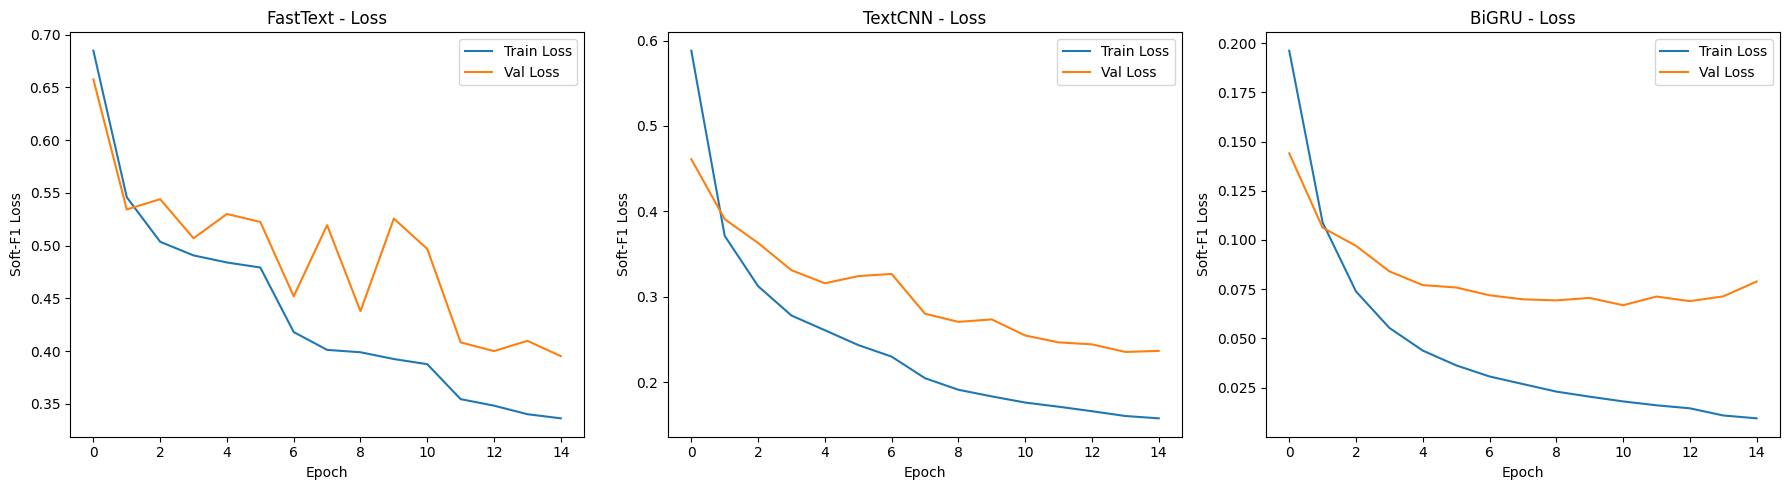

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} - Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Soft-F1 Loss')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Individual Model Evaluation

In [46]:
score_names = ['1 star', '2 stars', '3 stars', '4 stars', '5 stars']
y_test_labels = np.argmax(y_test, axis=1)

individual_preds = {}
for name, model in models.items():
    y_pred = model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    individual_preds[name] = y_pred
    print(f'\n{"="*50}')
    print(f'{name} - Test Results')
    print(f'{"="*50}')
    print(classification_report(y_test_labels, y_pred_labels, target_names=score_names, digits=4))


FastText - Test Results
              precision    recall  f1-score   support

      1 star     0.7284    0.6899    0.7086      2325
     2 stars     0.4421    0.6810    0.5361      1323
     3 stars     0.5230    0.5829    0.5513      1894
     4 stars     0.6088    0.6130    0.6109      4773
     5 stars     0.7584    0.6396    0.6939      5374

    accuracy                         0.6356     15689
   macro avg     0.6121    0.6413    0.6202     15689
weighted avg     0.6534    0.6356    0.6403     15689


TextCNN - Test Results
              precision    recall  f1-score   support

      1 star     0.8389    0.8245    0.8317      2325
     2 stars     0.7749    0.8065    0.7904      1323
     3 stars     0.7283    0.7545    0.7412      1894
     4 stars     0.7600    0.7253    0.7423      4773
     5 stars     0.7789    0.7987    0.7887      5374

    accuracy                         0.7755     15689
   macro avg     0.7762    0.7819    0.7788     15689
weighted avg     0.7756    0

## 9. Ensemble & Threshold Tuning

In [47]:
from sklearn.metrics import f1_score

model_f1_scores = {}
for name, probs in individual_preds.items():
    preds = np.argmax(probs, axis=1)
    model_f1_scores[name] = f1_score(y_test_labels, preds, average='macro')
    print(f'{name} Macro F1: {model_f1_scores[name]:.4f}')

total_f1 = sum(model_f1_scores.values())
model_weights = {name: score/total_f1 for name, score in model_f1_scores.items()}
print(f'\nEnsemble weights: {model_weights}')

ensemble_pred = np.zeros_like(list(individual_preds.values())[0])
for name, probs in individual_preds.items():
    ensemble_pred += model_weights[name] * probs

ensemble_labels = np.argmax(ensemble_pred, axis=1)
print(f'\nWeighted Ensemble (no tuning):')
print(classification_report(y_test_labels, ensemble_labels, target_names=score_names, digits=4))

FastText Macro F1: 0.6202
TextCNN Macro F1: 0.7788
BiGRU Macro F1: 0.8491

Ensemble weights: {'FastText': 0.2758662781179474, 'TextCNN': 0.34643501673866817, 'BiGRU': 0.37769870514338455}

Weighted Ensemble (no tuning):
              precision    recall  f1-score   support

      1 star     0.8671    0.8615    0.8643      2325
     2 stars     0.8041    0.8594    0.8308      1323
     3 stars     0.7819    0.7930    0.7874      1894
     4 stars     0.7626    0.7517    0.7571      4773
     5 stars     0.7966    0.7914    0.7940      5374

    accuracy                         0.7957     15689
   macro avg     0.8025    0.8114    0.8067     15689
weighted avg     0.7956    0.7957    0.7955     15689



In [48]:
def apply_offsets(probs, offsets):
    adjusted = probs.copy()
    for cls_idx, offset in offsets.items():
        adjusted[:, cls_idx] += offset
    return np.argmax(adjusted, axis=1)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

best_f1 = 0
best_offsets = {}

coarse_range = np.arange(-0.2, 0.21, 0.05)
print('Coarse grid search...')
for o0 in coarse_range:
    for o1 in coarse_range:
        for o2 in coarse_range:
            for o3 in coarse_range:
                offsets = {0: o0, 1: o1, 2: o2, 3: o3}
                preds = apply_offsets(ensemble_pred, offsets)
                f1 = macro_f1(y_test_labels, preds)
                if f1 > best_f1:
                    best_f1 = f1
                    best_offsets = offsets.copy()

print(f'Coarse best: {best_offsets}, F1: {best_f1:.4f}')

fine_range = np.arange(-0.1, 0.11, 0.02)
print('Fine grid search...')
for o0 in fine_range:
    for o1 in fine_range:
        for o2 in fine_range:
            for o3 in fine_range:
                offsets = {0: o0, 1: o1, 2: o2, 3: o3}
                preds = apply_offsets(ensemble_pred, offsets)
                f1 = macro_f1(y_test_labels, preds)
                if f1 > best_f1:
                    best_f1 = f1
                    best_offsets = offsets.copy()

print(f'\nFinal best offsets: {best_offsets}')
print(f'Final best Macro F1: {best_f1:.4f}')

Coarse grid search...
Coarse best: {0: np.float64(-0.10000000000000003), 1: np.float64(-0.2), 2: np.float64(-0.2), 3: np.float64(-5.551115123125783e-17)}, F1: 0.8126
Fine grid search...

Final best offsets: {0: np.float64(-0.10000000000000003), 1: np.float64(-0.2), 2: np.float64(-0.2), 3: np.float64(-5.551115123125783e-17)}
Final best Macro F1: 0.8126


In [49]:
final_preds = apply_offsets(ensemble_pred, best_offsets)

print('=' * 60)
print('FINAL ENSEMBLE RESULTS (with threshold tuning)')
print('=' * 60)
print(classification_report(y_test_labels, final_preds, target_names=score_names, digits=4))

FINAL ENSEMBLE RESULTS (with threshold tuning)
              precision    recall  f1-score   support

      1 star     0.8706    0.8654    0.8680      2325
     2 stars     0.8370    0.8345    0.8357      1323
     3 stars     0.8392    0.7714    0.8039      1894
     4 stars     0.7508    0.7737    0.7621      4773
     5 stars     0.7916    0.7953    0.7935      5374

    accuracy                         0.7995     15689
   macro avg     0.8178    0.8081    0.8126     15689
weighted avg     0.8005    0.7995    0.7998     15689



## 10. Visualizations

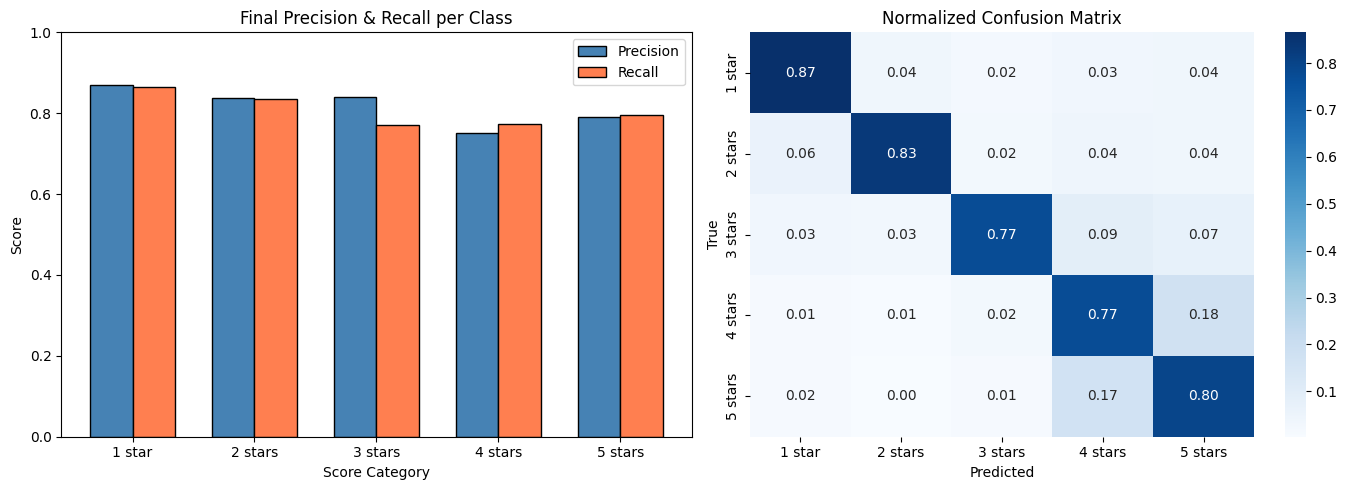

In [50]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_labels, final_preds, average=None
)

x_pos = np.arange(len(score_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x_pos - width/2, precision, width, label='Precision', color='steelblue', edgecolor='black')
axes[0].bar(x_pos + width/2, recall, width, label='Recall', color='coral', edgecolor='black')
axes[0].set_xlabel('Score Category')
axes[0].set_ylabel('Score')
axes[0].set_title('Final Precision & Recall per Class')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(score_names)
axes[0].legend()
axes[0].set_ylim(0, 1)

cm = confusion_matrix(y_test_labels, final_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=score_names, yticklabels=score_names, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [51]:
print(f'\nMacro Precision: {np.mean(precision):.4f}')
print(f'Macro Recall: {np.mean(recall):.4f}')
print(f'Macro F1: {np.mean(f1):.4f}')
print(f'\nPer-class F1:')
for i, (name, score) in enumerate(zip(score_names, f1)):
    print(f'  {name}: {score:.4f}')


Macro Precision: 0.8178
Macro Recall: 0.8081
Macro F1: 0.8126

Per-class F1:
  1 star: 0.8680
  2 stars: 0.8357
  3 stars: 0.8039
  4 stars: 0.7621
  5 stars: 0.7935
